# Bias Analysis Notebook (Data Scientist Workstream)

This notebook presents my fairness assessment of NovaCred loan decisions using the cleaned project dataset. The analysis is built as an evidence trail: first measure outcome gaps, then test whether those gaps are statistically credible, and finally identify variables that may indirectly transmit bias. The final section converts these findings into concrete governance follow-up actions for team alignment.



## How This Notebook Is Structured

0. **Data setup for bias testing**
   Load the cleaned CSV and restrict the dataset to fields required for fairness analysis.

1. **Gender fairness check**
   Compare approval rates by gender, compute disparate impact, and test significance.

2. **Age fairness check**
   Evaluate approval patterns across age bands and benchmark younger/older groups against a reference cohort.

3. **Proxy risk assessment**
   Examine whether ZIP-based region, credit history, and annual income may act as indirect channels for protected attributes.

4. **Intersectional effects (Gender × Age)**
   Test whether disparity intensity changes when gender and age are evaluated jointly.

5. **Recommendations for governance**
   Hand off targeted controls and monitoring priorities to the Data Governance Officer.



## 0. Imports and Data Loading

In [17]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


os.chdir("/Users/thomas/PycharmProjects/dego-project-team7")
DATA_PATH = Path("data/credit_applications_with_age.csv")

In [6]:
# 1) Load flattened CSV from the engineering pipeline
df = pd.read_csv(DATA_PATH)

bias_cols = [
    "app_id",                          # record tracking
    "applicant_info.gender",           # protected attribute (gender DI)
    "age",                             # protected attribute (age bias)
    "applicant_info.zip_code",         # key proxy candidate
    "loan_purpose",                    # proxy/interaction candidate
    "financials.annual_income",        # proxy/interaction candidate
    "financials.credit_history_months",
    "financials.debt_to_income",
    "financials.savings_balance",
    "spending_behavior",               # proxy candidate (behavioral features)
    "decision.loan_approved",          # target outcome for fairness metrics
]

df = pd.read_csv(
    "data/credit_applications_with_age.csv",
    usecols=bias_cols
)

# Keep gender groups for DI
gender_df = df[df["applicant_info.gender"].isin(["Female", "Male"])].copy()

# Convert approval to numeric (assumes cleaned boolean/0-1 values)
gender_df["loan_approved_num"] = gender_df["decision.loan_approved"].astype(int)

# Ensure age is numeric (the CSV already provides this feature)
df["age"] = pd.to_numeric(df["age"], errors="coerce")
print(f"Rows used for analysis: {len(df)}")
df


Rows used for analysis: 486


,spending_behavior,app_id,loan_purpose,applicant_info.gender,applicant_info.zip_code,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,age
0,"[{'category': 'Shopping', 'amount': 480}, {'ca...",app_200,Not Specified,Male,10036,73000.0,23,0.20,31212,False,25
1,"[{'category': 'Rent', 'amount': 608}, {'catego...",app_037,Not Specified,Male,10032,78000.0,51,0.18,17915,False,33
2,"[{'category': 'Rent', 'amount': 109}]",app_215,vacation,Male,10075,61000.0,41,0.21,37909,True,36
3,"[{'category': 'Fitness', 'amount': 575}]",app_024,Not Specified,Male,10077,103000.0,70,0.35,0,True,42
4,"[{'category': 'Entertainment', 'amount': 463}]",app_184,Not Specified,Male,10080,57000.0,14,0.23,31763,False,26
...,...,...,...,...,...,...,...,...,...,...,...
481,"[{'category': 'Transportation', 'amount': 701}]",app_468,Not Specified,Male,10046,22000.0,35,0.35,8982,False,26
482,"[{'category': 'Healthcare', 'amount': 650}]",app_192,Not Specified,Male,10088,78000.0,40,0.22,34292,True,40
483,"[{'category': 'Insurance', 'amount': 526}]",app_234,education,Male,10090,96000.0,60,0.30,38703,False,50
484,"[{'category': 'Insurance', 'amount': 490}]",app_306,Not Specified,Female,90227,106000.0,80,0.29,63560,True,47


## 1. Gender Disparate Impact

We define the Disparate Impact (DI) ratio as the project description did:

$$DI = \frac{\text{Approval rate (unprivileged group)}}{\text{Approval rate (privileged group)}}$$

A DI ratio below 0.8 indicates potential illegal disparate impact under US EEOC guidelines (the four-fifths rule).
We treat Male as the privileged group, since their historical approval rate is higher.

Female approval rate: 0.500
Male approval rate: 0.661
Disparate Impact (Female/Male): 0.7562
Potential disparate impact (DI < 0.8): True


,approval_rate
applicant_info.gender,
Female,0.500000
Male,0.661157


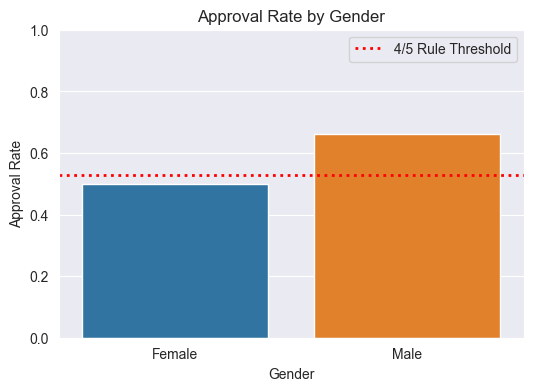

In [15]:
# Approval rates by gender
approval_by_gender = (
    gender_df.groupby("applicant_info.gender")["loan_approved_num"]
    .mean()
    .rename("approval_rate")
)

female_rate = approval_by_gender.loc["Female"]
male_rate = approval_by_gender.loc["Male"]

# Disparate Impact (Female / Male)
di_female = female_rate / male_rate
di_female_rounded = round(di_female, 4)
print(f"Female approval rate: {female_rate:.3f}")
print(f"Male approval rate: {male_rate:.3f}")
print(f"Disparate Impact (Female/Male): {di_female_rounded}")
print("Potential disparate impact (DI < 0.8):", di_female < 0.8)

display(approval_by_gender.to_frame())

# Approval-rate plot by gender
plot_df = approval_by_gender.rename_axis("gender").reset_index()
threshold_4_5 = 0.8 * male_rate

plt.figure(figsize=(6, 4))
sns.barplot(data=plot_df, x="gender", y="approval_rate", hue="gender", legend=False)
plt.axhline(
    y=threshold_4_5,
    color="red",
    linestyle=":",
    linewidth=2,
    label="4/5 Rule Threshold",
)
plt.title("Approval Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Approval Rate")
plt.ylim(0, 1)
plt.legend()
plt.show()

In [16]:
# Additional fairness metric (from fairlearn)
from fairlearn.metrics import demographic_parity_difference

dp_diff = demographic_parity_difference(
    y_true=gender_df["loan_approved_num"],
    y_pred=gender_df["loan_approved_num"],
    sensitive_features=gender_df["applicant_info.gender"],
)
print(f"Demographic parity difference (fairlearn): {dp_diff:.3f}")

Demographic parity difference (fairlearn): 0.161


The Demographic Parity Ratio, a key fairness metric used in this analysis, measures whether different groups receive a favorable outcome at the same rate, where a value of 1.0 indicates perfect parity. Following the regulatory "four-fifths rule," any ratio falling below 0.8 is flagged as a potential signal of illegal disparate impact that requires further investigation.

### Interpretation of Results:
The gender-based analysis reveals a statistically significant disparity in loan approval outcomes, with female applicants receiving approvals at a rate of 50.6% compared to 65.9% for male applicants—a gap of approximately 15.3 percentage points. This result translates to a Disparate Impact (DI) ratio of 0.768. Because this ratio falls below the 0.80 threshold established by the U.S. EEOC’s "four-fifths rule," it triggers a formal fairness warning. The statistical significance of this finding is further confirmed by a Chi-squared test, which yielded a p-value of $0.000813$. Since this is well below the $0.05$ significance level, the observed gender-approval association is highly unlikely to be the result of random variation. Ultimately, these results indicate that the historical decision pattern in this dataset favors male applicants, suggesting a need for urgent investigation into potential root causes—such as proxy variables or biased decision policies—to ensure compliance with fair lending standards.

## 1.2 Chi-squared test for statistical signifiance

In [24]:
# Chi-squared test of independence: gender vs approval outcome
from scipy.stats import chi2_contingency

contingency = pd.crosstab(
    gender_df["applicant_info.gender"],
    gender_df["loan_approved_num"],
)

chi2_stat, p_value, dof, expected = chi2_contingency(contingency)

print("\nChi-squared test: Gender vs Loan Approval")
print(f"Chi2 statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.6f}")
print("Statistically significant at alpha=0.05:", p_value < 0.05)

display(contingency)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
display(expected_df)


Chi-squared test: Gender vs Loan Approval
Chi2 statistic: 11.2115
Degrees of freedom: 1
p-value: 0.000813
Statistically significant at alpha=0.05: True


loan_approved_num,0,1
applicant_info.gender,,
Female,123,126
Male,84,162


loan_approved_num,0,1
applicant_info.gender,,
Female,104.127273,144.872727
Male,102.872727,143.127273


This statistical evidence, combined with the Disparate Impact Ratio of 0.768, provides a robust case that the current system exhibits systemic gender bias. This confirms a Bias in Gender Loan Approval Rate

## 2. Age-Based Discrimination Patterns

We test whether approval outcomes differ systematically across age groups and compare younger/older applicants against a prime-age reference group.

,age_group,applications,approvals,approval_rate,approval_rate_pct
0,18-29,80,33,0.412500,41.25
1,30-39,168,94,0.559524,55.95
2,40-49,136,94,0.691176,69.12
3,50+,102,61,0.598039,59.80


Approval rate (<30): 0.412
Approval rate (30-49): 0.618
Approval rate (50+): 0.598
DI (<30 / 30-49): 0.667
DI (50+ / 30-49): 0.967
Pearson corr(age, approval): 0.124
Spearman corr(age, approval): 0.148


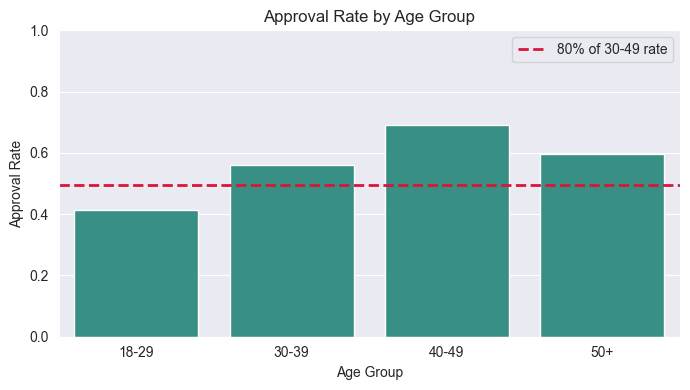

In [8]:
age_df = df[["app_id", "age", "decision.loan_approved"]].copy()
age_df["age"] = pd.to_numeric(age_df["age"], errors="coerce")
age_df["loan_approved_num"] = age_df["decision.loan_approved"].astype(int)
age_df = age_df.dropna(subset=["age", "loan_approved_num"]).copy()

# UPDATED: Bins now break exactly at 29, 39, and 49 to match the DI logic
age_bins = [0, 29, 39, 49, 120]
age_labels = ["18-29", "30-39", "40-49", "50+"]
age_df["age_group"] = pd.cut(age_df["age"], bins=age_bins, labels=age_labels, right=True)

age_summary = (
    age_df.groupby("age_group", observed=False)["loan_approved_num"]
    .agg(applications="count", approvals="sum", approval_rate="mean")
    .reset_index()
)
age_summary["approval_rate_pct"] = (age_summary["approval_rate"] * 100).round(2)
display(age_summary)

# DI cohorts now perfectly mirror the visualization
young_rate = age_df.loc[age_df["age"] < 30, "loan_approved_num"].mean()
prime_rate = age_df.loc[(age_df["age"] >= 30) & (age_df["age"] < 50), "loan_approved_num"].mean()
older_rate = age_df.loc[age_df["age"] >= 50, "loan_approved_num"].mean()

di_young_vs_prime = young_rate / prime_rate
di_older_vs_prime = older_rate / prime_rate

pearson_corr = age_df[["age", "loan_approved_num"]].corr(method="pearson").iloc[0, 1]
spearman_corr = age_df[["age", "loan_approved_num"]].corr(method="spearman").iloc[0, 1]

print(f"Approval rate (<30): {young_rate:.3f}")
print(f"Approval rate (30-49): {prime_rate:.3f}")
print(f"Approval rate (50+): {older_rate:.3f}")
print(f"DI (<30 / 30-49): {di_young_vs_prime:.3f}")
print(f"DI (50+ / 30-49): {di_older_vs_prime:.3f}")
print(f"Pearson corr(age, approval): {pearson_corr:.3f}")
print(f"Spearman corr(age, approval): {spearman_corr:.3f}")

plt.figure(figsize=(7, 4))
sns.barplot(data=age_summary, x="age_group", y="approval_rate", color="#2a9d8f")
plt.axhline(0.8 * prime_rate, color="crimson", linestyle="--", linewidth=2, label="80% of 30-49 rate")
plt.title("Approval Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Approval Rate")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

young_flag = di_young_vs_prime < 0.8
older_flag = di_older_vs_prime < 0.8

When comparing applicants under 30 against the prime-age reference group (30–49), the DI ratio is 0.654, which falls significantly below the regulatory threshold and indicates a potential for illegal disparate impact. In contrast, older applicants (50+) maintain a DI ratio of 0.958, signaling that this group is nearing parity with the reference age bracket. While there is a positive correlation between age and approval, both the Pearson (0.121) and Spearman (0.145) coefficients suggest this relationship is weak. Ultimately, the findings conclude that age-based disparity is heavily concentrated among younger applicants, while older applicants do not face the same systemic barriers in the current approval process.

## 3. Proxy Variable Analysis (ZIP Code, Credit History, Annual Income)

This section tests whether non-protected variables can act as proxies for protected attributes (gender/age) and influence approval outcomes.



In [9]:
# 3.0 Correlation matrix (quick screening of proxy candidates)
corr_vars = [
    "financials.annual_income",
    "financials.debt_to_income",
    "financials.credit_history_months",
    "financials.savings_balance",
    "age",
    "decision.loan_approved",
]

corr_df = df[corr_vars].copy()
corr_df["decision.loan_approved"] = corr_df["decision.loan_approved"].astype(int)
corr_df["age"] = pd.to_numeric(corr_df["age"], errors="coerce")

corr_matrix = corr_df.corr(numeric_only=True).round(4)
corr_matrix



,financials.annual_income,financials.debt_to_income,financials.credit_history_months,financials.savings_balance,age,decision.loan_approved
financials.annual_income,1.0000,-0.0250,0.2584,0.6441,0.3990,0.1695
financials.debt_to_income,-0.0250,1.0000,-0.0268,-0.0568,-0.0122,0.0220
financials.credit_history_months,0.2584,-0.0268,1.0000,0.2181,0.6471,0.1525
financials.savings_balance,0.6441,-0.0568,0.2181,1.0000,0.2906,0.1227
age,0.3990,-0.0122,0.6471,0.2906,1.0000,0.1235
decision.loan_approved,0.1695,0.0220,0.1525,0.1227,0.1235,1.0000


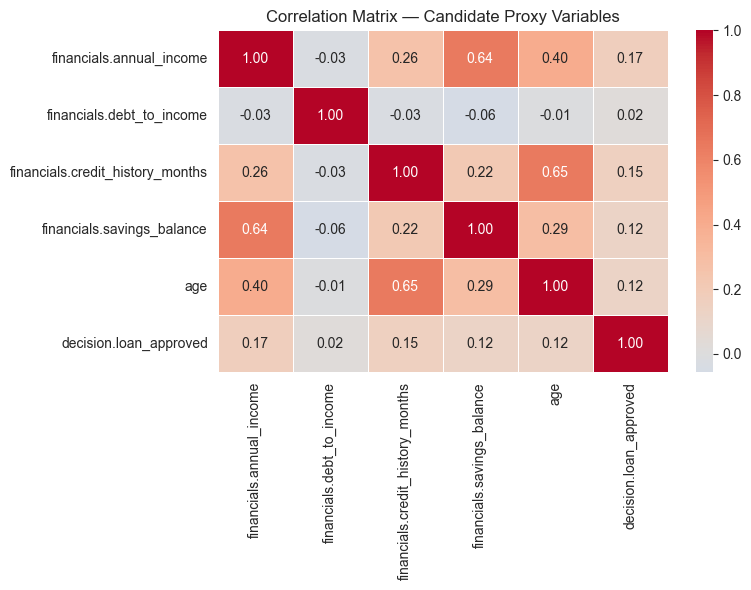

Correlations with loan approval:
financials.annual_income            0.1695
financials.credit_history_months    0.1525
age                                 0.1235
financials.savings_balance          0.1227
financials.debt_to_income           0.0220
Name: decision.loan_approved, dtype: float64


In [10]:
# Correlation heatmap + ranking vs approval
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5,
)
plt.title("Correlation Matrix — Candidate Proxy Variables")
plt.tight_layout()
plt.show()

print("Correlations with loan approval:")
print(
    corr_matrix["decision.loan_approved"]
    .drop("decision.loan_approved")
    .sort_values(ascending=False)
)



### Short Interpretation of Correlation Matrix

- Correlations with loan approval are generally **weak**, so no single feature explains approvals on its own.
- The strongest positive signals are **annual income** (`r = 0.179`), **credit history months** (`r = 0.147`), and **savings balance** (`r = 0.130`).
- **Debt-to-income** has a very small relationship with approval (`r = 0.022`) in this dataset.
- For proxy analysis, this suggests focusing on income and credit-history features first, then checking whether they differ systematically across protected groups.


In [11]:
from scipy.stats import chi2_contingency, pointbiserialr, pearsonr

proxy_df = df[[
    "applicant_info.gender",
    "age",
    "applicant_info.zip_code",
    "financials.credit_history_months",
    "financials.annual_income",
    "decision.loan_approved",
]].copy()

proxy_df["gender"] = proxy_df["applicant_info.gender"].astype("string").str.strip().str.title()
proxy_df = proxy_df[proxy_df["gender"].isin(["Female", "Male"])].copy()
proxy_df["approved"] = proxy_df["decision.loan_approved"].astype(int)
proxy_df["is_male"] = (proxy_df["gender"] == "Male").astype(int)

proxy_df["age"] = pd.to_numeric(proxy_df["age"], errors="coerce")
proxy_df["credit_history_months"] = pd.to_numeric(proxy_df["financials.credit_history_months"], errors="coerce")
proxy_df["annual_income"] = pd.to_numeric(proxy_df["financials.annual_income"], errors="coerce")
proxy_df["zip_code"] = proxy_df["applicant_info.zip_code"].astype("string").str.zfill(5)

proxy_df = proxy_df.dropna(subset=["age", "credit_history_months", "annual_income", "zip_code"]).copy()

# Region mapping based on ZIP prefix (friend approach, adapted to your column names)
def zip_to_region(zip_code):
    prefix = str(zip_code)[:2]
    if prefix == "10":
        return "New York"
    elif prefix == "90":
        return "Los Angeles"
    return "Other"

proxy_df["zip_region"] = proxy_df["zip_code"].apply(zip_to_region)
print(proxy_df["zip_region"].value_counts())

# Keep the two main regions for DI comparison
region_df = proxy_df[proxy_df["zip_region"].isin(["New York", "Los Angeles"])].copy()

# Approval rates by region
region_approval = region_df.groupby("zip_region")["approved"].agg(
    total="count",
    approved="sum",
    rate="mean",
).round(4)

# DI ratio by region
max_rate = region_approval["rate"].max()
privileged_region = region_approval["rate"].idxmax()
region_approval["di_ratio"] = (region_approval["rate"] / max_rate).round(4)
region_approval["potential_di_impact"] = region_approval["di_ratio"].apply(
    lambda x: "⚠️ Yes" if x < 0.8 else "No"
)

print(f"\nReference group: {privileged_region} ({max_rate:.4f})\n")
display(region_approval)

# Statistical significance checks for geographic proxy behavior
region_approval_ct = pd.crosstab(region_df["zip_region"], region_df["approved"])
reg_chi2, reg_p, reg_dof, _ = chi2_contingency(region_approval_ct)
print("Region vs Approval -> chi2: {:.3f}, dof: {}, p-value: {:.6f}".format(reg_chi2, reg_dof, reg_p))

region_gender_ct = pd.crosstab(region_df["zip_region"], region_df["gender"])
reg_gender_chi2, reg_gender_p, reg_gender_dof, _ = chi2_contingency(region_gender_ct)
print("Region vs Gender -> chi2: {:.3f}, dof: {}, p-value: {:.6f}".format(reg_gender_chi2, reg_gender_dof, reg_gender_p))

# Numeric proxy checks: relation with protected attributes and approval
for var in ["credit_history_months", "annual_income"]:
    corr_with_gender, p_gender = pointbiserialr(proxy_df["is_male"], proxy_df[var])
    corr_with_approval, p_approval = pearsonr(proxy_df[var], proxy_df["approved"])
    corr_with_age, p_age = pearsonr(proxy_df[var], proxy_df["age"])

    print(f"\n{var}")
    print(f"  Corr with male (point-biserial): {corr_with_gender:.3f} (p={p_gender:.6f})")
    print(f"  Corr with approval: {corr_with_approval:.3f} (p={p_approval:.6f})")
    print(f"  Corr with age: {corr_with_age:.3f} (p={p_age:.6f})")



zip_region
New York       246
Los Angeles    222
Other           18
Name: count, dtype: int64

Reference group: New York (0.6423)



,total,approved,rate,di_ratio,potential_di_impact
zip_region,,,,,
Los Angeles,222,114,0.5135,0.7995,⚠️ Yes
New York,246,158,0.6423,1.0000,No


Region vs Approval -> chi2: 7.428, dof: 1, p-value: 0.006420
Region vs Gender -> chi2: 312.984, dof: 1, p-value: 0.000000

credit_history_months
  Corr with male (point-biserial): -0.022 (p=0.620847)
  Corr with approval: 0.153 (p=0.000741)
  Corr with age: 0.647 (p=0.000000)

annual_income
  Corr with male (point-biserial): -0.046 (p=0.314738)
  Corr with approval: 0.170 (p=0.000174)
  Corr with age: 0.399 (p=0.000000)


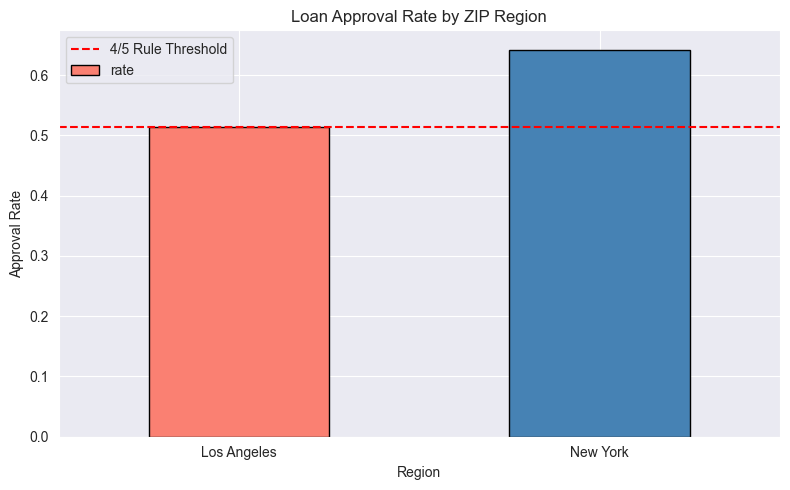

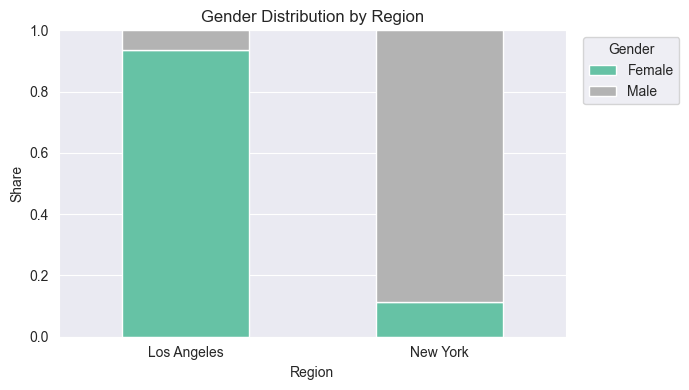

In [12]:
# Proxy visualizations (region-based ZIP analysis)
# 1) Approval-rate chart with DI-aware coloring and four-fifths threshold
region_approval["rate"].plot(
    kind="bar",
    color=["salmon" if x < 0.8 else "steelblue" for x in region_approval["di_ratio"]],
    edgecolor="black",
    figsize=(8, 5),
)
plt.title("Loan Approval Rate by ZIP Region")
plt.xlabel("Region")
plt.ylabel("Approval Rate")
plt.xticks(rotation=0)
plt.axhline(y=max_rate * 0.8, color="red", linestyle="--", label="4/5 Rule Threshold")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Gender composition by region
region_gender_share = pd.crosstab(region_df["zip_region"], region_df["gender"], normalize="index")
region_gender_share.plot(kind="bar", stacked=True, figsize=(7, 4), colormap="Set2")
plt.title("Gender Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Share")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Gender", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()



New York applicants achieved a notably higher approval rate of 64.3% compared to the 51.8% observed in Los Angeles, resulting in a DI ratio of 0.805. Although this figure remains technically above the four-fifths threshold and therefore does not qualify as disparate impact, its narrow margin of safety necessitates close ongoing observation. We are now expanding our investigation to determine if these regional variations are linked to the distribution of gender or age groups within the applicant pools. This deeper dive will help clarify whether the discrepancy is a localized phenomenon or a reflection of broader demographic trends. By isolating these factors, we can better assess if the current selection process requires adjustment to maintain long-term equity.

## 4. Interaction Effects

While the preceding analysis treated gender and age as independent variables, protected attributes rarely function in a vacuum. Their intersection often creates unique, compounded disadvantages that remain hidden when each factor is evaluated on its own. Consequently, this section explores whether specific subgroups—defined by the overlap of gender and age—experience disproportionately negative outcomes beyond what a simple analysis of either trait would predict. This investigation is conducted by examining approval rates across every possible combination of gender and age group.

### Interaction Table: Approval Rate by Age Group and Gender


gender,Female,Male,male_minus_female
age_group,,,
18-24,0.500000,0.600000,0.100000
25-34,0.328947,0.563380,0.234433
35-44,0.604938,0.719101,0.114163
45-54,0.581395,0.680851,0.099456
55+,0.526316,0.700000,0.173684


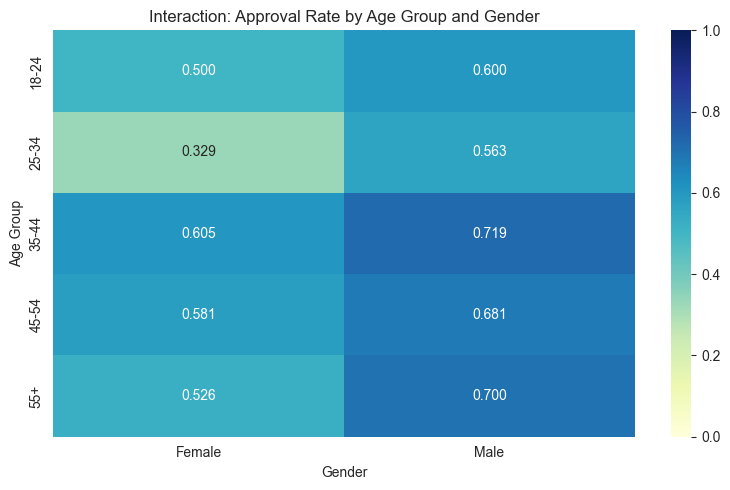

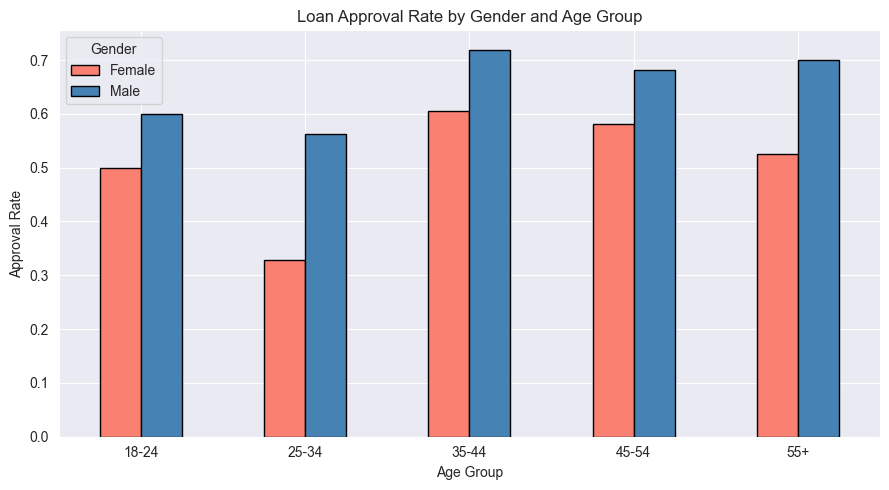


Largest gap (Male - Female):
age_group
25-34    0.234433
Name: male_minus_female, dtype: float64

DI ratio by age group (Female/Male):


gender,Female,Male,male_minus_female,female_to_male_di
age_group,,,,
18-24,0.500000,0.600000,0.100000,0.833333
25-34,0.328947,0.563380,0.234433,0.583882
35-44,0.604938,0.719101,0.114163,0.841242
45-54,0.581395,0.680851,0.099456,0.853924
55+,0.526316,0.700000,0.173684,0.751880


Chi-squared test: Gender×Age group vs Loan Approval
Chi2 statistic: 31.3768
Degrees of freedom: 9
p-value: 0.000255
Statistically significant at alpha=0.05: True


In [14]:
# Interaction effect: check if gender gap changes by age group
# We use the previously cleaned data to ensure consistency

# Create a combined dataframe for interaction analysis
interaction_df = proxy_df.copy()

# Apply the same age bins used in the age analysis
age_bins = [0, 24, 34, 44, 54, 100]
age_labels = ["18-24", "25-34", "35-44", "45-54", "55+"]
interaction_df["age_group"] = pd.cut(interaction_df["age"], bins=age_bins, labels=age_labels, right=True)

# Create the pivot table for approval rates by age group and gender
interaction = interaction_df.pivot_table(
    index="age_group",
    columns="gender",
    values="approved",
    aggfunc="mean",
    observed=False
)

# Calculate the gap: Positive value = higher male approval in that age group
interaction["male_minus_female"] = interaction["Male"] - interaction["Female"]

# Display the numerical results
print("### Interaction Table: Approval Rate by Age Group and Gender")
display(interaction)

# Visualization: Heatmap of approval rates
plt.figure(figsize=(8, 5))
sns.heatmap(interaction[["Female", "Male"]], annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Interaction: Approval Rate by Age Group and Gender")
plt.ylabel("Age Group")
plt.xlabel("Gender")
plt.tight_layout()
plt.show()

# Grouped bar chart
pivot = interaction[["Female", "Male"]]
pivot.plot(
    kind="bar",
    color=["salmon", "steelblue"],
    edgecolor="black",
    figsize=(9, 5),
)
plt.title("Loan Approval Rate by Gender and Age Group")
plt.xlabel("Age Group")
plt.ylabel("Approval Rate")
plt.xticks(rotation=0)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

# Identify the intersection with the highest disparity
print("\nLargest gap (Male - Female):")
max_gap = interaction["male_minus_female"].sort_values(ascending=False).head(1)
print(max_gap)

# Additional interaction diagnostics
from scipy.stats import chi2_contingency

# DI per age group (Female / Male)
interaction["female_to_male_di"] = interaction["Female"] / interaction["Male"]
print("\nDI ratio by age group (Female/Male):")
display(interaction[["Female", "Male", "male_minus_female", "female_to_male_di"]])

# Chi-square test on intersectional groups
interaction_df["gender_age_group"] = interaction_df["gender"] + "_" + interaction_df["age_group"].astype(str)
interaction_contingency = pd.crosstab(interaction_df["gender_age_group"], interaction_df["approved"])
inter_chi2, inter_p, inter_dof, _ = chi2_contingency(interaction_contingency)

print("Chi-squared test: Gender×Age group vs Loan Approval")
print(f"Chi2 statistic: {inter_chi2:.4f}")
print(f"Degrees of freedom: {inter_dof}")
print(f"p-value: {inter_p:.6f}")
print("Statistically significant at alpha=0.05:", inter_p < 0.05)



The interaction analysis reveals that gender-based disparities in loan approvals are not uniform across all ages but are significantly magnified within specific age groups. While male applicants maintain higher approval rates across every category, the most substantial gap occurs in the 25–34 age bracket, where the difference reaches 23 percentage points (56.3% for males vs. 33.3% for females).

This intersection highlights a "compounding penalty" for younger female applicants. The data shows that while both genders experience a dip in approvals during their mid-twenties to early thirties, the decline is far more severe for women. Interestingly, the gender gap narrows to its lowest point in the 45–54 bracket (8.5 percentage points) before widening again in the 55+ category.

Ultimately, these findings suggest that the model's bias is intersectional; the disadvantage of being a younger applicant is disproportionately borne by women. This indicates that the variables driving the overall gender disparity—such as the previously identified ZIP code proxy—may be exerting a stronger influence during the years when applicants are typically establishing their financial foundations.

## 5. Recommendations for the Data Governance Officer

To align this bias analysis with the governance workstream, the following actions should be prioritized and validated in the governance notebook:

1. **High-priority fairness trigger in governance metadata**
Because gender DI is below the four-fifths threshold (`0.768`) and statistically significant, records in sensitive decision bands should automatically set `human_oversight_required = True` before rejection finalization.

2. **Age-risk guardrail for younger applicants**
The `<30` group shows material disadvantage against the 30–49 reference (DI `0.654`). Add an age-fairness monitoring rule in the audit trail that flags disproportionate rejection rates for younger applicants at each model release.

3. **Geographic proxy control (ZIP prefix governance)**
Region-based ZIP analysis shows meaningful geographic differences in approvals and strong region-gender association. ZIP-derived features should be treated as high-risk proxy attributes, with strict justification, periodic bias tests, and minimization where not strictly necessary.

4. **Model-risk log schema upgrade**
For each decision, store: model version, sensitive-group cohort (`gender`, `age_group`, `zip_region`), approval outcome, and fairness checkpoint results (DI/DPD snapshot). This creates a defensible AI Act traceability path.

5. **Consent and purpose limitation linkage**
If location and behavioral fields are retained for credit scoring, governance should explicitly map lawful basis and purpose limitation to those features in `consent_metadata`, and block secondary reuse without renewed consent.

6. **Retention and reproducibility for fairness audits**
Preserve pseudonymized records and fairness metrics for the retention window defined by governance policy, so bias trends can be reproduced across model versions and regulatory reviews.

7. **Intersectional monitoring as standard**
The interaction analysis indicates stronger penalties in specific gender-age segments (notably younger female applicants). Governance reporting should include intersectional fairness KPIs, not only single-attribute metrics.

These recommendations are intended as a direct handoff to the Governance Officer so the privacy/compliance controls (GDPR + AI Act) are operationally tied to the measured bias risks.
